# Google Trends Data Analysis 

Philadelphians take their football seriously. Major sporting events have even resulted in riots and deaths from fans enthusiastically climbing light poles in voctory parades. Thus analysis answers the question of whether the Philadelphia Eagles are a flight risk. 

Using Pennsylvania Department of Transportation crash records spanning 2005 to 2024, I set out to explore whether famous Philadelphia Eagles game months are actually more dangerous to be on the road in Philadelphia. The short answer: kind of. The more interesting answer is where.


In [190]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

In [202]:
crash = pd.read_csv('data/cleaned_crash_data.csv', low_memory=False)
    #just keep athlete ID, name, born_country, lat and long
#zips = pd.read_csv('data/philadelphia_zip_boundaries.geojson')
zip_gpd=gpd.read_file('data/Zipcodes_Poly.geojson').to_crs(crs=4326)

#crashes during major sporting events
    #when do they happen- make a timeline with major sporting events in dotted lines-- 
            #colors for diff philly sports teams? and a barplot or other way of visualizing frequency of crashes
    #where do they happen: closer to the stadiums in south philly, presumably

The dataset covers every recorded crash in Pennsylvania over nearly two decades, including exact coordinates, injury counts, and fatalities. To focus the analysis, I filtered down to football season — September through February — and matched each crash to a Philadelphia zip code using geographic boundary files. The result was a month-by-month picture of road danger across the city.

In [198]:
#summary and keeping columns I want
crash = crash[['DEC_LATITUDE', 'DEC_LONGITUDE', 'CRASH_MONTH', 'CRASH_YEAR', 'FATAL_COUNT', 'TOT_INJ_COUNT']]
# KEEPING CRASH LOCATION, DATES, AND THE NUMBER OF SERIOUS INJURIES AND DEATHS THE DATASET
#find the average number of car crashes for a given year and month
crash.head()


,DEC_LATITUDE,DEC_LONGITUDE,CRASH_MONTH,CRASH_YEAR,FATAL_COUNT,TOT_INJ_COUNT
0,40.428007,-75.080509,1,2005,0,0
1,40.101623,-75.229772,1,2005,0,0
2,40.070757,-75.106579,1,2005,0,0
3,40.442375,-75.348946,1,2005,1,1
4,NaN,NaN,1,2005,0,1


In [199]:
#subset to football season (with a month of padding on either side)
football_months = [9, 10, 11, 12, 1, 2]
crash = crash[crash['CRASH_MONTH'].isin(football_months)]



In [200]:
#crash.to_csv('cleaned_crash_data.csv', index = False)
#github said the crash data was too large so I had to make a smaller version to get the file to push

In [168]:
#creating a mapable datset
crash = gpd.GeoDataFrame(crash, geometry=gpd.points_from_xy(x=crash['DEC_LONGITUDE'], y=crash['DEC_LATITUDE']))
crash = crash_map.set_crs(crs=4326)
crash.head()

,DEC_LATITUDE,DEC_LONGITUDE,CRASH_MONTH,CRASH_YEAR,FATAL_COUNT,TOT_INJ_COUNT,geometry
0,40.428007,-75.080509,1,2005,0,0,POINT (-75.08051 40.42801)
1,40.101623,-75.229772,1,2005,0,0,POINT (-75.22977 40.10162)
2,40.070757,-75.106579,1,2005,0,0,POINT (-75.10658 40.07076)
3,40.442375,-75.348946,1,2005,1,1,POINT (-75.34895 40.44238)
4,NaN,NaN,1,2005,0,1,POINT (NaN NaN)


In [169]:
#find the average number of car crashes for a given year and month
#create a date on the 1st of each month
crash['day'] = 1
    #because I'm assigning every day 1, grouping by month and year should aggregate my data by month and year 
crash['date'] = pd.to_datetime(crash[['CRASH_YEAR', 'CRASH_MONTH']].assign(day=1).rename(columns={'CRASH_YEAR': 'year', 'CRASH_MONTH': 'month'}))
    #I struggled converting to datetime so had to troubleshoot errors, which led me to the renaming columns approach


In [170]:
#join crash points to zip code polygons
zcrash = gpd.sjoin(crash, zip_gpd, how='left', predicate='within')

,DEC_LATITUDE,DEC_LONGITUDE,CRASH_MONTH,CRASH_YEAR,FATAL_COUNT,TOT_INJ_COUNT,geometry,day,date,index_right,OBJECTID,CODE,COD,Shape__Area,Shape__Length
0,40.428007,-75.080509,1,2005,0,0,POINT (-75.08051 40.42801),1,2005-01-01,NaN,NaN,NaN,NaN,NaN,NaN
1,40.101623,-75.229772,1,2005,0,0,POINT (-75.22977 40.10162),1,2005-01-01,NaN,NaN,NaN,NaN,NaN,NaN
2,40.070757,-75.106579,1,2005,0,0,POINT (-75.10658 40.07076),1,2005-01-01,NaN,NaN,NaN,NaN,NaN,NaN
3,40.442375,-75.348946,1,2005,1,1,POINT (-75.34895 40.44238),1,2005-01-01,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,1,2005,0,1,POINT (NaN NaN),1,2005-01-01,NaN,NaN,NaN,NaN,NaN,NaN


In [171]:
# grouping by date and zip code so that I can find the average crashes in a zip for certain months/days
zcrash = zcrash.groupby(['date', 'CODE']).aggregate(
    fatalities = ('FATAL_COUNT', 'sum'),
    injuries = ('TOT_INJ_COUNT', 'sum')
).reset_index()


,date,CODE,fatalities,injuries
0,2005-01-01,19102,0,1
1,2005-01-01,19103,0,7
2,2005-01-01,19104,0,44
3,2005-01-01,19106,0,6
4,2005-01-01,19107,0,14
...,...,...,...,...
11109,2024-12-01,19150,0,5
11110,2024-12-01,19151,0,4
11111,2024-12-01,19152,0,8
11112,2024-12-01,19153,0,13


In [172]:
#count the injuries and fatalities for each day to compare with dates of eagles games
crash_ag = crash.groupby('date').aggregate(fatalities = ('FATAL_COUNT', 'sum'), injuries = ('TOT_INJ_COUNT', 'sum'))

avg_fat = crash_ag['fatalities'].mean()
avg_inj = crash_ag['injuries'].mean()

To identify "important" Eagles games, I compiled a list of notable matchups — playoff runs, blowout wins, historic moments — and flagged the months in which they occurred. These are the green bars in the charts below.


In [173]:
#keep only important dates for the eagles over the course of the dataset
eagles_games = { #I found an article that had the dates of major eagles games online, and I asked chatgpt to turn the text into a data dictionary
    #I then madea all the days in the set equal to 1, because my crash data is generalized to month
    '2005-01-01': 'NFC Championship: Eagles 27, Falcons 10',
    '2006-01-01': 'Wild Card: Eagles 23, Giants 20 (OT)',
    '2008-12-01': 'Week 17: Eagles 44, Cowboys 6',
    '2011-01-01': 'Wild Card: Packers 21, Eagles 16',
    '2013-09-01': 'Week 1: Eagles 33, Redskins 27 (Chip Kelly debut)',
    '2013-12-01': 'Week 16: Eagles 54, Bears 11',
    '2017-09-01': 'Week 2: Eagles 20, Chiefs 17',
    '2017-10-01': 'Week 8: Eagles 33, 49ers 10',
    '2018-01-01': 'Divisional: Eagles 15, Falcons 10',
    '2018-01-01': 'NFC Championship: Eagles 38, Vikings 7',
    '2018-09-01': 'Week 1: Eagles 18, Falcons 12 (Super Bowl celebration)',
    '2022-09-01': 'Week 2: Eagles 24, Vikings 7 (MNF)',
    '2022-10-01': 'Week 4: Eagles 29, Jaguars 21',
    '2023-01-01': 'NFC Championship: Eagles 31, 49ers 7',
    '2023-12-01': 'Week 16: Eagles 33, Giants 25 (Christmas)',
    '2026-01-01': 'Wild Card: Eagles vs 49ers (Barkley dominates)'
}

In [174]:
#taking the eagles dataset and converting to datetime so it's comprable to my existing dataset
eagles_dates = pd.to_datetime(list(eagles_games.keys()))

# Create colors: green if date matches an Eagles game month, grey otherwise
colors = ['green' if date in eagles_dates else 'grey' for date in crash_ag.index] #looked this up

#making sur ethat things are in datetime format so the code doesn't give me an error when I'm plotting: 
eagles_dates = pd.to_datetime(list(eagles_games.keys()))

Looking at monthly fatalities over the full dataset, the signal is noisy. Fatal crashes are relatively rare events, and the average hovers around 22 per month during football season. Some Eagles game months spike above that average — and some don't. It's hard to draw a clean line.


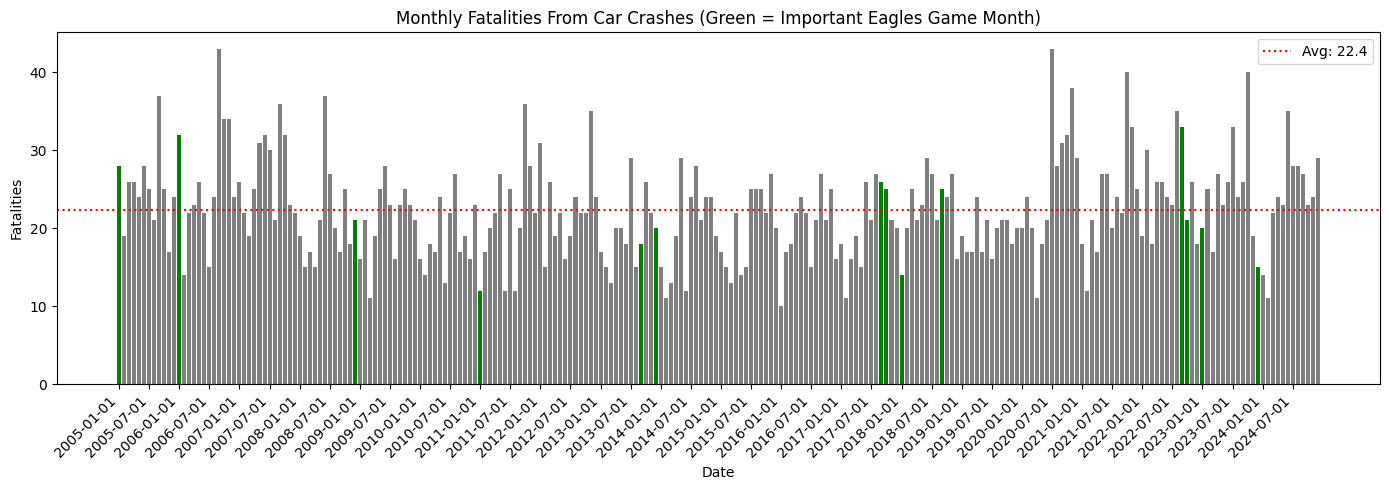

In [175]:
#making a fatalities plot
fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(crash_ag))
ax.bar(x, crash_ag['fatalities'], color=colors, width=0.8)

# Set x-tick labels (show every nth label to avoid crowding-- looked this up)
n = 6  # show every 6th label
ax.set_xticks(x[::n])
ax.set_xticklabels([str(d.date()) for d in crash_ag.index[::n]], rotation=45, ha='right')

#line to indicate average fatalities
ax.axhline(y=avg_fat, linestyle='dotted', color='red', label=f'Avg: {avg_fat:.1f}')

ax.set_xlabel('Date')
ax.set_ylabel('Fatalities')
ax.set_title('Monthly Fatalities From Car Crashes (Green = Important Eagles Game Month)')
ax.legend()

plt.tight_layout()
plt.show()

The injuries chart tells a more consistent story. With an average of around 2,200 injuries per football-season month, several of the green-highlighted Eagles months cluster toward the higher end of the distribution. Again, it's not a perfect pattern — plenty of non-Eagles months are bad too — but the visual suggests that the months surrounding major games are at least not safer.

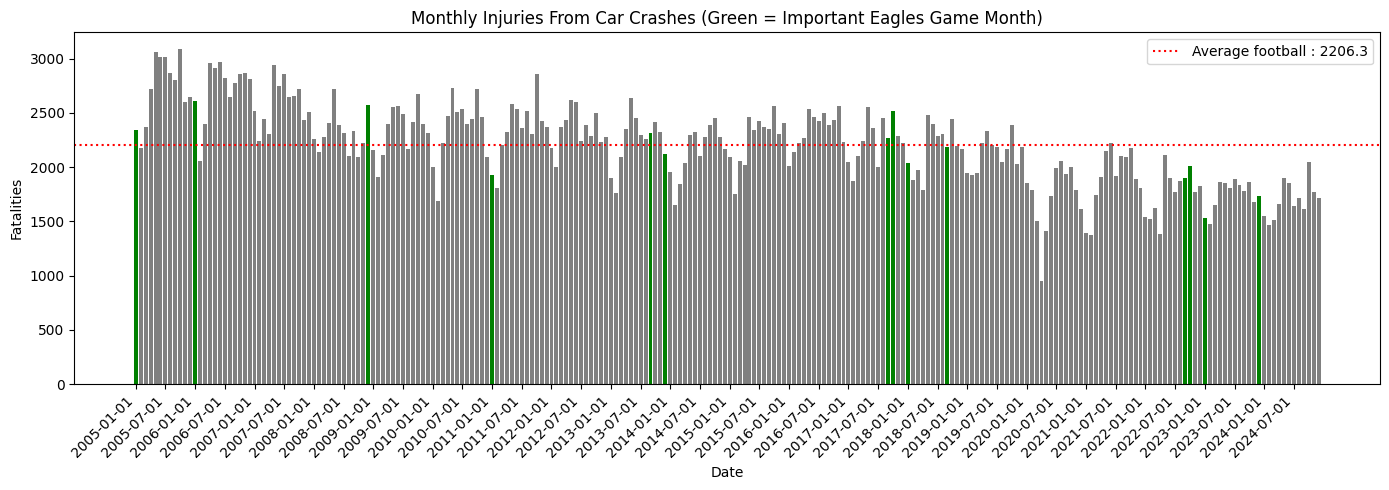

In [176]:
fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(crash_ag))
ax.bar(x, crash_ag['injuries'], color=colors, width=0.8)

# Set x-tick labels (show every nth label to avoid crowding-- looked this up)
n = 6  # show every 6th label
ax.set_xticks(x[::n])
ax.set_xticklabels([str(d.date()) for d in crash_ag.index[::n]], rotation=45, ha='right')

#line to indicate average fatalities
ax.axhline(y=avg_inj, linestyle='dotted', color='red', label=f'Average football : {avg_inj:.1f}')

ax.set_xlabel('Date')
ax.set_ylabel('Fatalities')
ax.set_title('Monthly Injuries From Car Crashes (Green = Important Eagles Game Month)')
ax.legend()

plt.tight_layout()
plt.show()

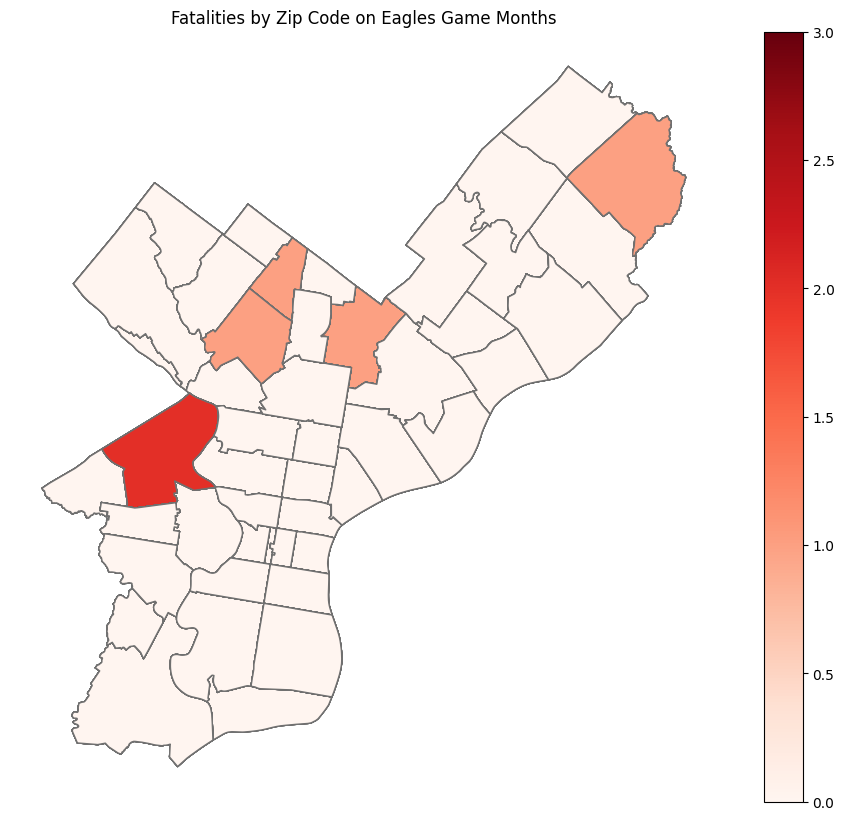

In [183]:
#graphing where in philly car crashes happen on important eagles game nights

#making a dataset of only crash dates
zcrash_eagles = zcrash[zcrash['date'].isin(eagles_dates)]

# # Then aggregate by zip
# eagles_by_zip = zcrash_eagles.groupby('CODE').aggregate(
#     fatalities = ('FATAL_COUNT', 'sum'),
#     injuries = ('TOT_INJ_COUNT', 'sum')
# ).reset_index()

# merge with the zip code dataset
zip_eagles = zip_gpd.merge(zcrash_eagles, on='CODE', how='left')
zip_eagles['fatalities'] = zip_eagles['fatalities'].fillna(0)

#plot
zip_eagles.plot(column='fatalities', legend=True, cmap='Reds', edgecolor='#707070', figsize=(12,10))
plt.title('Fatalities by Zip Code on Eagles Game Months')
plt.axis('off')
plt.show()

Mapping fatalities by zip code during Eagles game months, one neighborhood stands out clearly in the west of the city — a deep red patch in what appears to be the Cobbs Creek or Kingsessing area. This is notably not South Philadelphia, where Lincoln Financial Field sits, which might seem counterintuitive. But it suggests that the danger isn't concentrated around the stadium itself — it's spread across the city, and particularly into neighborhoods that may have less infrastructure or more late-night driving activity.

zip_eagles.plot(column='injuries', legend=True, cmap='Reds', edgecolor='#707070', figsize=(12,10))
plt.title('Injuries by Zip Code on Eagles Game Months')
plt.axis('off')
plt.show()

The injuries map broadens that picture considerably. West and Northeast Philadelphia both show up as hotspots, with a wide swath of the city seeing elevated injury counts. The injury distribution is more diffuse than the fatality map, which makes sense — injuries from crashes are far more common than fatalities, so the geographic spread is wider and the variation across neighborhoods is more pronounced.


# Conclusion 

To be fair about what this analysis can and can't say: the data is aggregated by month, not by game day. That means we can't isolate the specific hours after a final whistle — just the calendar month in which a major game happened to fall. A lot of other things happen in January and December that could also drive crash rates up, from holiday drinking to bad weather.

Still, as a first pass, the pattern is suggestive enough to be worth investigating further. Philadelphia's most passionate sports city has some of the most chaotic roads in the country — and if the Eagles are at least partially responsible for that, the data is starting to make the case.